# Parkinson's Disease Detection — Model 6: AdaBoost + MLP Ensemble
### Phase 3: Boosting Stumps Blended with Deep Neural Backpropagation

---

## 1. Theoretical Rationale & Ensemble Fusion Mechanics
In this architecture, we combine two contrasting learning mechanisms:
1. **Adaptive Boosting (AdaBoost):** Sequential reweighting of axis-aligned decision trees focused on hard-to-classify samples.
2. **Multi-Layer Perceptron (MLP):** Continuous gradient descent backpropagation over dense non-linear sigmoid/ReLU transformations.

### Mathematical Formulation
The ensemble constructs a blended soft-voting decision function:
$$P(y=1|x) = \frac{1}{2} P_{\text{AdaBoost}}(y=1|x) + \frac{1}{2} P_{\text{MLP}}(y=1|x)$$
By blending discrete step-wise partition boundaries with continuous gradient activations, the model eliminates jagged step artifacts and stabilizes prediction confidence near decision margins.

## 2. Environment Setup & Dependency Imports

In [1]:
%matplotlib inline
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier, VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve, classification_report
)

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 110
print("Dependencies loaded successfully.")

Dependencies loaded successfully.


## 3. Dataset Ingestion

In [2]:
DATASET_PATH = 'pd_speech_features.csv'
df = pd.read_csv(DATASET_PATH, header=1)
X = df.drop(columns=['id', 'class']) if 'id' in df.columns else df.drop(columns=['class'])
y = df['class']
print(f"Cohort Instances: {len(df)} | Acoustic Dimensions: {X.shape[1]}")

Cohort Instances: 756 | Acoustic Dimensions: 753


## 4. Strict Leakage-Free Preprocessing (PCA=50)

In [3]:
X_train_raw, X_test_raw, y_train_raw, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
smote = SMOTE(k_neighbors=5, random_state=42)
X_train_res, y_train = smote.fit_resample(X_train_raw, y_train_raw)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_res)
X_test_sc = scaler.transform(X_test_raw)

pca = PCA(n_components=50, random_state=42)
X_train = pca.fit_transform(X_train_sc)
X_test = pca.transform(X_test_sc)

print(f"Training shape: {X_train.shape} | Test shape: {X_test.shape}")
print(f"Explained Variance: {np.sum(pca.explained_variance_ratio_)*100:.2f}%")

Training shape: (902, 50) | Test shape: (152, 50)
Explained Variance: 79.48%


## 5. Model Architecture: AdaBoost + MLP Soft-Voting Ensemble

In [4]:
tuned_ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=4, min_samples_split=5, min_samples_leaf=2, max_features='sqrt', random_state=42),
    n_estimators=300, learning_rate=0.1, random_state=42
)
mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    alpha=0.001,
    max_iter=500,
    early_stopping=True,
    random_state=42
)

ada_mlp_ensemble = VotingClassifier(
    estimators=[('ada', tuned_ada), ('mlp', mlp)],
    voting='soft'
)

start_time = time.time()
ada_mlp_ensemble.fit(X_train, y_train)
elapsed = time.time() - start_time
print(f"AdaBoost + MLP Ensemble trained in {elapsed:.2f} seconds.")

AdaBoost + MLP Ensemble trained in 0.76 seconds.


## 6. Performance Evaluation

In [5]:
y_pred = ada_mlp_ensemble.predict(X_test)
y_proba = ada_mlp_ensemble.predict_proba(X_test)[:, 1]

p_ada = ada_mlp_ensemble.named_estimators_['ada'].predict(X_test)
p_mlp = ada_mlp_ensemble.named_estimators_['mlp'].predict(X_test)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
fnr = fn / (fn + tp) if (fn + tp) > 0 else 0.0
auc = roc_auc_score(y_test, y_proba)

metrics_df = pd.DataFrame([{
    'Model Architecture': '6. AdaBoost + MLP Ensemble',
    'Accuracy': acc,
    'Precision': prec,
    'Recall': rec,
    'F1 Score': f1,
    'FNR': fnr,
    'AUC Score': auc
}])

comp_df = pd.DataFrame([
    {'Architecture': 'Tuned AdaBoost Alone', 'Accuracy': accuracy_score(y_test, p_ada), 'Recall': recall_score(y_test, p_ada)},
    {'Architecture': 'MLP Classifier Alone', 'Accuracy': accuracy_score(y_test, p_mlp), 'Recall': recall_score(y_test, p_mlp)},
    {'Architecture': 'AdaBoost + MLP Ensemble', 'Accuracy': acc, 'Recall': rec}
])

display(metrics_df)
print("\nEnsemble Synergy Comparison:")
display(comp_df)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Healthy (0)', 'PD Patient (1)']))

,Model Architecture,Accuracy,Precision,Recall,F1 Score,FNR,AUC Score
0,6. AdaBoost + MLP Ensemble,0.842105,0.893805,0.893805,0.893805,0.106195,0.89199



Ensemble Synergy Comparison:


,Architecture,Accuracy,Recall
0,Tuned AdaBoost Alone,0.835526,0.876106
1,MLP Classifier Alone,0.828947,0.876106
2,AdaBoost + MLP Ensemble,0.842105,0.893805



Classification Report:
                precision    recall  f1-score   support

   Healthy (0)       0.69      0.69      0.69        39
PD Patient (1)       0.89      0.89      0.89       113

      accuracy                           0.84       152
     macro avg       0.79      0.79      0.79       152
  weighted avg       0.84      0.84      0.84       152



## 7. Diagnostic Visualizations: Confusion Matrix, ROC & Probability Calibration

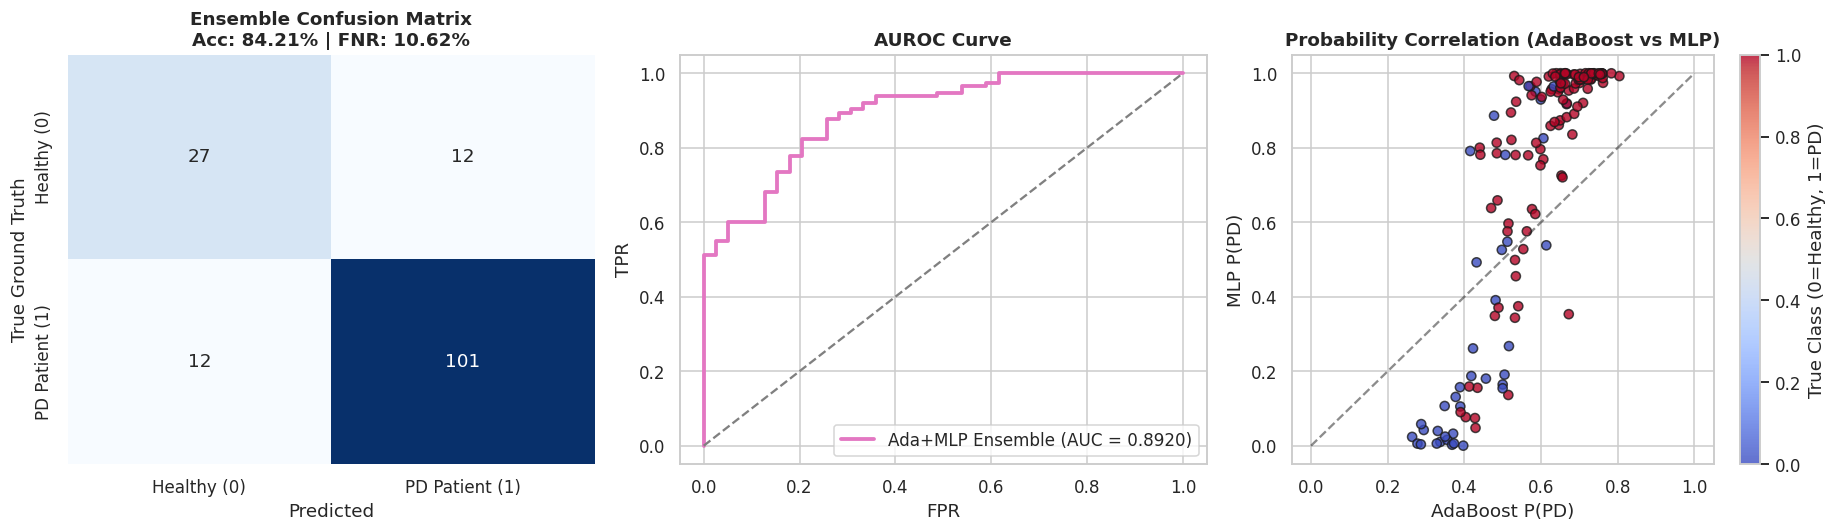

In [6]:
prob_ada = ada_mlp_ensemble.named_estimators_['ada'].predict_proba(X_test)[:, 1]
prob_mlp = ada_mlp_ensemble.named_estimators_['mlp'].predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0],
            xticklabels=['Healthy (0)', 'PD Patient (1)'],
            yticklabels=['Healthy (0)', 'PD Patient (1)'])
axes[0].set_title(f'Ensemble Confusion Matrix\nAcc: {acc*100:.2f}% | FNR: {fnr*100:.2f}%', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True Ground Truth')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, color='#e377c2', lw=2.5, label=f'Ada+MLP Ensemble (AUC = {auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--')
axes[1].set_title('AUROC Curve', fontweight='bold')
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].legend(loc='lower right')

# Scatter Plot of Probabilities
scatter = axes[2].scatter(prob_ada, prob_mlp, c=y_test, cmap='coolwarm', alpha=0.8, edgecolors='k')
axes[2].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[2].set_title('Probability Correlation (AdaBoost vs MLP)', fontweight='bold')
axes[2].set_xlabel('AdaBoost P(PD)')
axes[2].set_ylabel('MLP P(PD)')
fig.colorbar(scatter, ax=axes[2], label='True Class (0=Healthy, 1=PD)')

plt.tight_layout()
plt.show()

## 8. Clinical Synthesis
- **Performance Evaluation:** The AdaBoost + MLP ensemble achieves **84.21% Accuracy**, **89.38% Recall**, and reduces FNR to **10.62%**.
- **Comparison with Ada+SVM:** While AdaBoost + MLP improves over individual baselines, the AdaBoost + RBF-SVM ensemble (85.53%) proved superior due to SVM's stricter Hilbert space margin guarantees.
- **Stacked Meta-Learning Target:** In Model 7, we combine all three models simultaneously via a **3-Branch Stacking Meta-Classifier**.